In [63]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer
import glob

sns.set_theme()

In [64]:
current_location = Path.cwd()
PROJECT_ROOT = current_location.parent.parent

files = glob.glob(f"{PROJECT_ROOT}/data/youtube_comments/*.csv")
file_list = [ pd.read_csv(file) for file in files ]
file_list

[                                      COMMENT_ID  \
 0              z12rwfnyyrbsefonb232i5ehdxzkjzjs2   
 1            z130wpnwwnyuetxcn23xf5k5ynmkdpjrj04   
 2              z13vsfqirtavjvu0t22ezrgzyorwxhpf3   
 3            z12wjzc4eprnvja4304cgbbizuved35wxcs   
 4              z13xjfr42z3uxdz2223gx5rrzs3dt5hna   
 ..                                           ...   
 443  LneaDw26bFu3RCmyrWyP9S6wh1h9dBv3X95g1HzKAb4   
 444  LneaDw26bFsD65dtIvAEObWYIYnFTqQDKBek_Ypz3J8   
 445  LneaDw26bFuvs-8oWkLpAFa6g3QHpWD8k7sbbMP3Bg8   
 446        z12hfp2wmyuqztkw504cgblyxtbsxjuzeow0k   
 447          z13tsbc5vvn0hdozz04chjt51lq1cvris0k   
 
                              AUTHOR                        DATE  \
 0                       Lisa Wellas                         NaN   
 1                      jason graham  2015-05-29T02:26:10.652000   
 2                        Ajkal Khan                         NaN   
 3                     Dakota Taylor  2015-05-29T02:13:07.810000   
 4                    

In [65]:
data = pd.concat(file_list, axis=0, ignore_index=True)
data

,COMMENT_ID,AUTHOR,DATE,CONTENT,CLASS
0,z12rwfnyyrbsefonb232i5ehdxzkjzjs2,Lisa Wellas,NaN,+447935454150 lovely girl talk to me xxx﻿,1
1,z130wpnwwnyuetxcn23xf5k5ynmkdpjrj04,jason graham,2015-05-29T02:26:10.652000,I always end up coming back to this song<br />﻿,0
2,z13vsfqirtavjvu0t22ezrgzyorwxhpf3,Ajkal Khan,NaN,"my sister just received over 6,500 new <a rel=...",1
3,z12wjzc4eprnvja4304cgbbizuved35wxcs,Dakota Taylor,2015-05-29T02:13:07.810000,Cool﻿,0
4,z13xjfr42z3uxdz2223gx5rrzs3dt5hna,Jihad Naser,NaN,Hello I&#39;am from Palastine﻿,1
...,...,...,...,...,...
1950,z13lvr4iupatjlrem231yvpxolzvspwdl,Salty Croc,2014-07-22T04:20:37.489000,Like this comment for no reason﻿,1
1951,z12lxhrqdkyusbkji04cihtrvn3jvxnqszg0k,Bob Orton,2014-07-22T00:26:50.820000,love this song﻿,0
1952,z12xhdjrsxm3v550w22oynsjrnmvjhkvj,LuckyMusiqLive,2014-07-21T22:25:54.048000,this song is awesome. these guys are the best....,1
1953,z13msngo3qvwx1ym223pehqgouexzdmnm,xXxPWND 420xXx,2014-07-21T11:05:51.945000,HOW MANY THUMBS UP FOR LOUIS SAVING THE DAY!?!?﻿,1


In [66]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1955 entries, 0 to 1954
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   COMMENT_ID  1955 non-null   str  
 1   AUTHOR      1955 non-null   str  
 2   DATE        1710 non-null   str  
 3   CONTENT     1955 non-null   str  
 4   CLASS       1955 non-null   int64
dtypes: int64(1), str(4)
memory usage: 76.5 KB


In [67]:
data.drop(columns={"COMMENT_ID", "AUTHOR", "DATE"}, inplace=True)
data

,CONTENT,CLASS
0,+447935454150 lovely girl talk to me xxx﻿,1
1,I always end up coming back to this song<br />﻿,0
2,"my sister just received over 6,500 new <a rel=...",1
3,Cool﻿,0
4,Hello I&#39;am from Palastine﻿,1
...,...,...
1950,Like this comment for no reason﻿,1
1951,love this song﻿,0
1952,this song is awesome. these guys are the best....,1
1953,HOW MANY THUMBS UP FOR LOUIS SAVING THE DAY!?!?﻿,1


In [68]:
train_data, test_data = train_test_split(data, test_size=0.25, random_state=42, stratify=data["CLASS"])

In [69]:
converter = CountVectorizer(encoding="utf-8").fit(train_data["CONTENT"])
x_train = converter.transform(train_data["CONTENT"])
y_train = train_data["CLASS"]

x_test = converter.transform(test_data["CONTENT"])
y_test = test_data["CLASS"]

CLASS
1    0.513643
0    0.486357
Name: proportion, dtype: float64

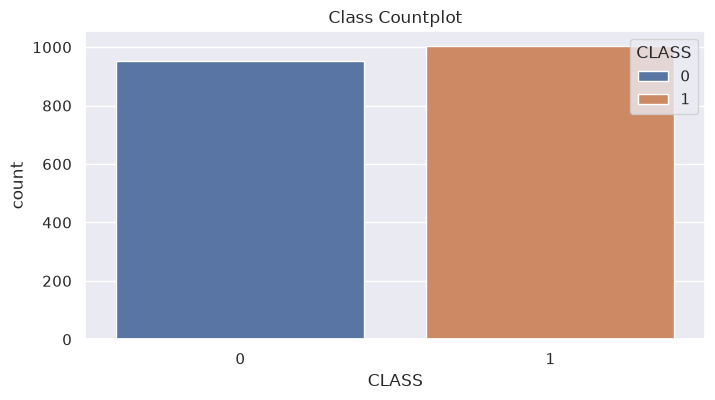

In [74]:
ratios = y_train.value_counts(normalize=True)
display(ratios)

fig, ax = plt.subplots()
fig.set_size_inches(8, 4)
ax.set_title("Class Countplot")
sns.countplot(data=data, x=data["CLASS"], hue="CLASS", ax=ax)
plt.show()

In [71]:
model = MultinomialNB(fit_prior=False).fit(x_train, y_train)

              precision    recall  f1-score   support

           0       0.94      0.93      0.93       238
           1       0.93      0.94      0.94       251

    accuracy                           0.94       489
   macro avg       0.94      0.94      0.94       489
weighted avg       0.94      0.94      0.94       489



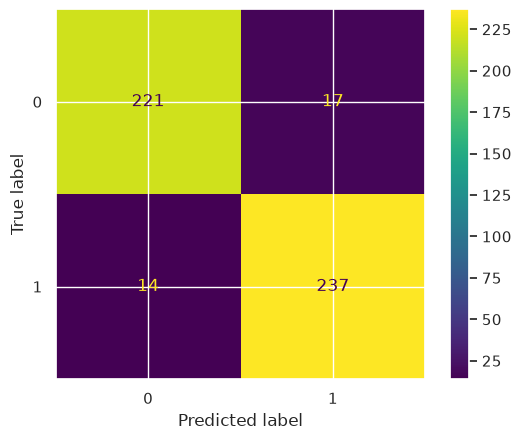

In [72]:
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()